In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import SimpleRNN, Dense, LSTM ,Dropout
from sklearn.preprocessing import MinMaxScaler


In [3]:
data=pd.read_csv('goog.csv',thousands=',')

In [4]:

df=data[['Close']].values
scaler=MinMaxScaler()
data_scaled=scaler.fit_transform(df)

In [5]:
train_size=int(len(data_scaled)*0.8)

In [6]:
train_data=data_scaled[:train_size]
test_data=data_scaled[train_size:]

In [10]:
steps=1
def create_dataset(dataset,steps):
    X=[]
    y=[]
    for i in range(steps,len(dataset)):
        X.append(dataset[i-steps:i,0])
        y.append(dataset[i,0])
    return np.array(X),np.array(y)
X_train,y_train=create_dataset(train_data,steps)
X_test,y_test=create_dataset(test_data,steps)
    

In [14]:
X_train=np.reshape(X_train,(X_train.shape[0],X_train.shape[1],1))
X_test=np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))

In [18]:
model=Sequential()
model.add(SimpleRNN(50,return_sequences=True,input_shape=(steps,1)))
model.add(SimpleRNN(50))
model.add(Dense(1))


model.compile(optimizer='adam',loss='mean_squared_error')
model.summary()

C:\Users\HP\anaconda4\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)             │ (None, 1, 50)               │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_5 (SimpleRNN)             │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.fit(X_train,y_train,epochs=20,batch_size=32)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0064
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0062
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0063
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0064
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0065
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0065 
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0063 
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0061 
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0059
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0058
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0059
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0059 
Epoch 13/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0059
Epoch 14/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0058
Epoch 15/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0058
Epoch 16/20
2/2 ━━━━━━━━━━━━━━

In [29]:
y_pred=model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


In [30]:
predicted_price=scaler.inverse_transform(y_pred)
real_price=scaler.inverse_transform(y_test.reshape(-1,1))

C:\Users\HP\AppData\Local\Temp\ipykernel_9960\2910945755.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


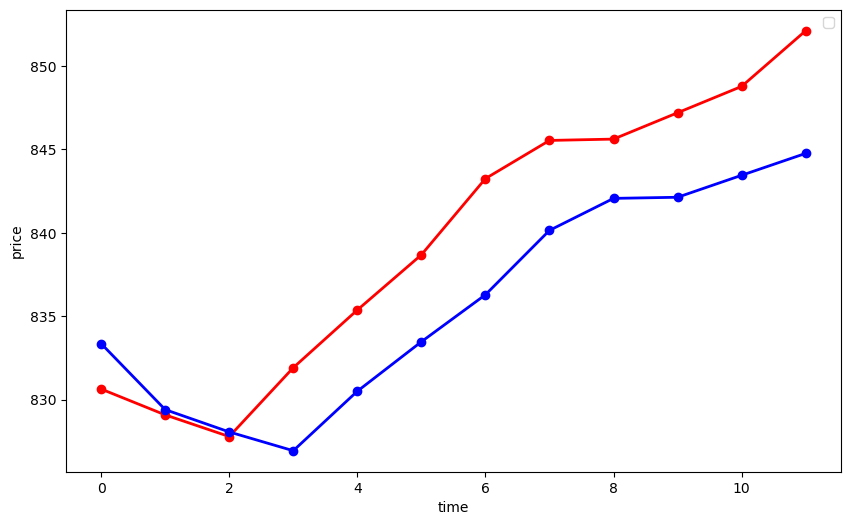

In [31]:
plt.figure(figsize=(10,6))

plt.plot(real_price,linewidth=2,marker='o',color='red')
plt.plot(predicted_price,linewidth=2,marker='o',color='blue')
plt.xlabel("time")
plt.ylabel("price")
plt.legend()
plt.show()